Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

========== FIRST 10 RECORDS ==========

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Ye

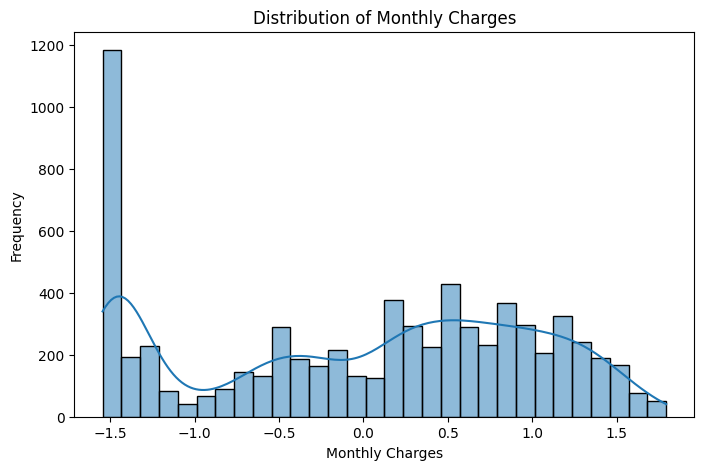

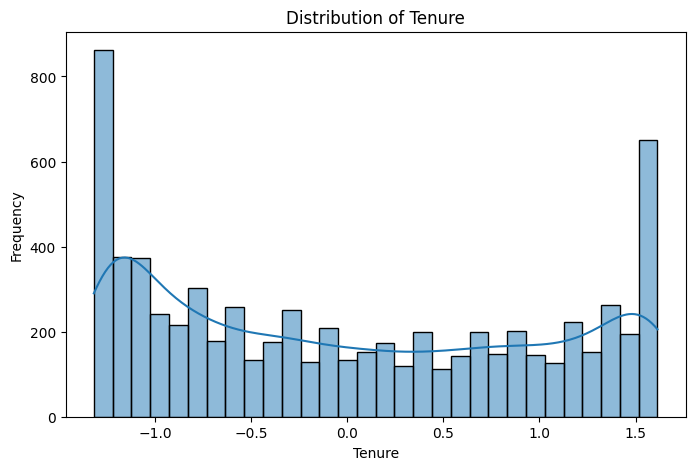

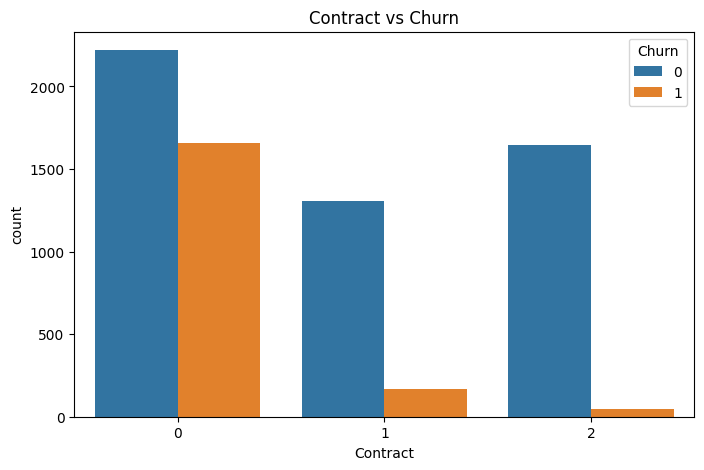

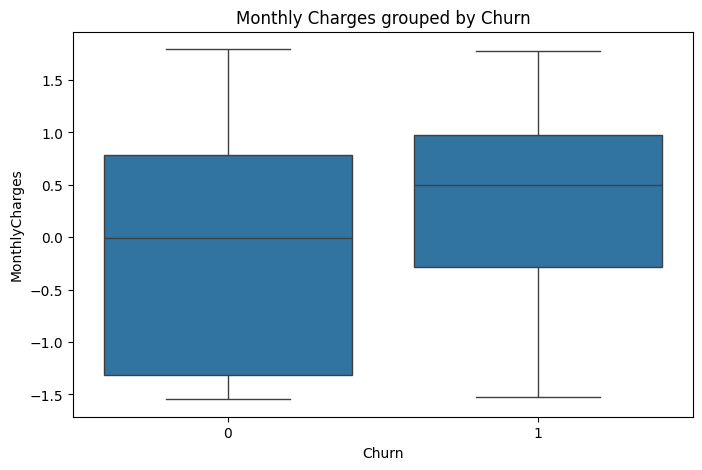

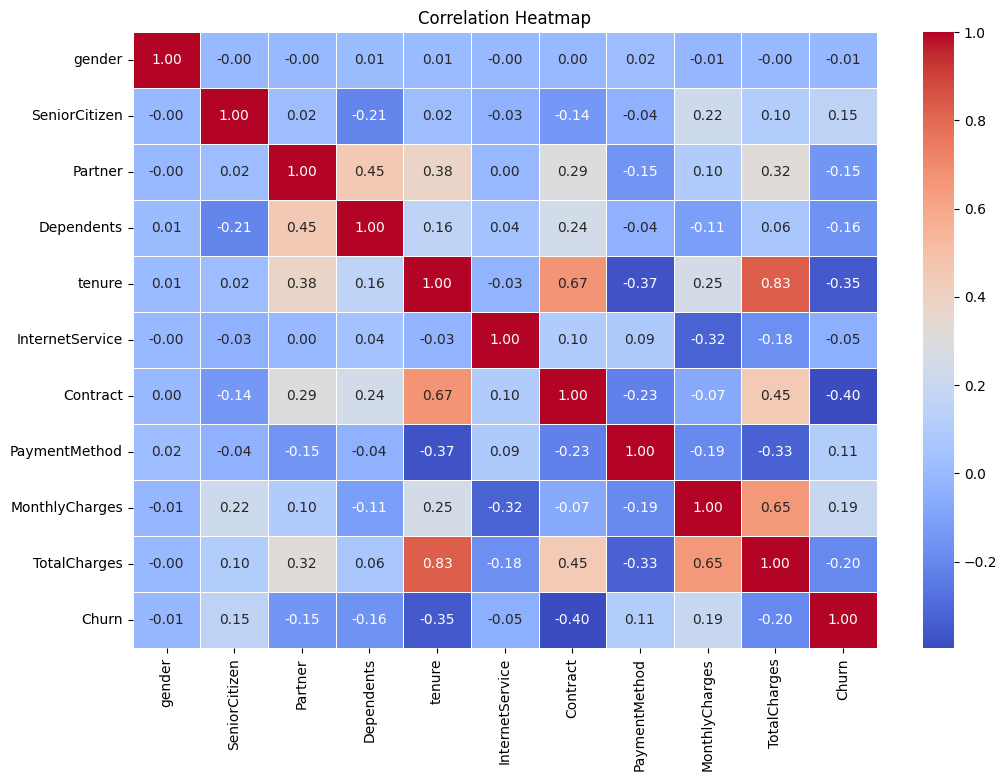


========== FINAL CLEANED DATASET ==========

   customerID  gender  SeniorCitizen  Partner  Dependents    tenure  \
0  7590-VHVEG       0              0        1           0 -1.277445   
1  5575-GNVDE       1              0        0           0  0.066327   
2  3668-QPYBK       1              0        0           0 -1.236724   
3  7795-CFOCW       1              0        0           0  0.514251   
4  9237-HQITU       0              0        0           0 -1.236724   

  PhoneService     MultipleLines  InternetService OnlineSecurity  ...  \
0           No  No phone service                0             No  ...   
1          Yes                No                0            Yes  ...   
2          Yes                No                0            Yes  ...   
3           No  No phone service                0            Yes  ...   
4          Yes                No                1             No  ...   

  DeviceProtection TechSupport StreamingTV StreamingMovies Contract  \
0               N

In [ ]:
# ==========================================================
# EXPERIMENT 1: DATA PREPROCESSING AND CLEANING
# Customer Churn Dataset
# ==========================================================

# -----------------------------
# STEP 1: Import Required Libraries
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# STEP 2: Upload Dataset
# -----------------------------

from google.colab import files

uploaded = files.upload()

# Automatically read the uploaded CSV file
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# -----------------------------
# Display Dataset
# -----------------------------

print("\n========== FIRST 10 RECORDS ==========\n")
print(df.head(10))

print("\n========== LAST 10 RECORDS ==========\n")
print(df.tail(10))

print("\n========== SHAPE ==========\n")
print(df.shape)

print("\n========== COLUMN NAMES ==========\n")
print(df.columns.tolist())

# -----------------------------
# STEP 3: Explore Dataset
# -----------------------------

print("\n========== DATASET INFORMATION ==========\n")
df.info()

print("\n========== SUMMARY STATISTICS ==========\n")
print(df.describe(include='all'))

print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())

print("\n========== DUPLICATE RECORDS ==========\n")
print(df.duplicated().sum())

# -----------------------------
# STEP 4(a): Remove Duplicate Records
# -----------------------------

df.drop_duplicates(inplace=True)

print("\nDuplicates after removal:", df.duplicated().sum())

# -----------------------------
# STEP 4(b): Convert TotalCharges to Numeric
# -----------------------------

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # -----------------------------
    # STEP 4(c): Replace Missing Values
    # Numerical -> Median
    # Categorical -> Mode
    # -----------------------------

    numeric_columns = df.select_dtypes(include=['int64','float64']).columns

    for col in numeric_columns:
        df[col].fillna(df[col].median(), inplace=True)

    categorical_columns = df.select_dtypes(include=['object']).columns

    for col in categorical_columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    print("\n========== MISSING VALUES AFTER CLEANING ==========\n")
    print(df.isnull().sum())

    # -----------------------------
    # STEP 5: Encode Categorical Columns
    # -----------------------------

    encoder = LabelEncoder()

    columns_to_encode = [
        'gender',
            'Partner',
                'Dependents',
                    'Contract',
                        'PaymentMethod',
                            'InternetService',
                                'Churn'
                                ]

    for col in columns_to_encode:
        if col in df.columns:
            df[col] = encoder.fit_transform(df[col])

    print("\nCategorical Encoding Completed.")

    # -----------------------------
    # STEP 6: Standardize Numerical Features
    # -----------------------------

    scaler = StandardScaler()

    columns_to_scale = [
        'tenure',
            'MonthlyCharges',
                'TotalCharges'
                ]

    available_columns = [col for col in columns_to_scale if col in df.columns]

    df[available_columns] = scaler.fit_transform(df[available_columns])

    print("\nStandardization Completed.")

    # -----------------------------
    # STEP 7: Distribution of MonthlyCharges
    # -----------------------------

    if 'MonthlyCharges' in df.columns:
        plt.figure(figsize=(8,5))
        sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
        plt.title("Distribution of Monthly Charges")
        plt.xlabel("Monthly Charges")
        plt.ylabel("Frequency")
        plt.show()

    # -----------------------------
    # Distribution of Tenure
    # -----------------------------

    if 'tenure' in df.columns:
        plt.figure(figsize=(8,5))
        sns.histplot(df['tenure'], bins=30, kde=True)
        plt.title("Distribution of Tenure")
        plt.xlabel("Tenure")
        plt.ylabel("Frequency")
        plt.show()

    # -----------------------------
    # STEP 8: Count Plot
    # Contract vs Churn
    # -----------------------------

    if 'Contract' in df.columns and 'Churn' in df.columns:
        plt.figure(figsize=(8,5))
        sns.countplot(data=df, x='Contract', hue='Churn')
        plt.title("Contract vs Churn")
        plt.show()

    # -----------------------------
    # STEP 9: Box Plot
    # MonthlyCharges vs Churn
    # -----------------------------

    if 'MonthlyCharges' in df.columns and 'Churn' in df.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
        plt.title("Monthly Charges grouped by Churn")
        plt.show()

    # -----------------------------
    # STEP 10: Correlation Heatmap
    # -----------------------------

    plt.figure(figsize=(12,8))

    correlation = df.corr(numeric_only=True)

    sns.heatmap(
        correlation,
            annot=True,
                cmap='coolwarm',
                    linewidths=0.5,
                        fmt=".2f"
                        )

    plt.title("Correlation Heatmap")
    plt.show()

    # -----------------------------
    # Final Dataset
    # -----------------------------

    print("\n========== FINAL CLEANED DATASET ==========\n")
    print(df.head())

    print("\nFinal Shape:", df.shape)

    # -----------------------------
    # Save Cleaned Dataset
    # -----------------------------

    df.to_csv("Cleaned_Customer_Churn.csv", index=False)

    print("\nCleaned dataset saved as 'Cleaned_Customer_Churn.csv'")